Total de observações (após lags): 990
Treino: 792 | Teste: 198
Período de teste: 2025-09-30 → 2026-04-15

Melhores parâmetros: {'svr__C': 50000, 'svr__epsilon': 100, 'svr__gamma': 0.01}

AVALIAÇÃO FINAL — SVR (teste: 20% final da série)
MAE  : 3178.61
RMSE : 4636.24
R²   : 0.9237


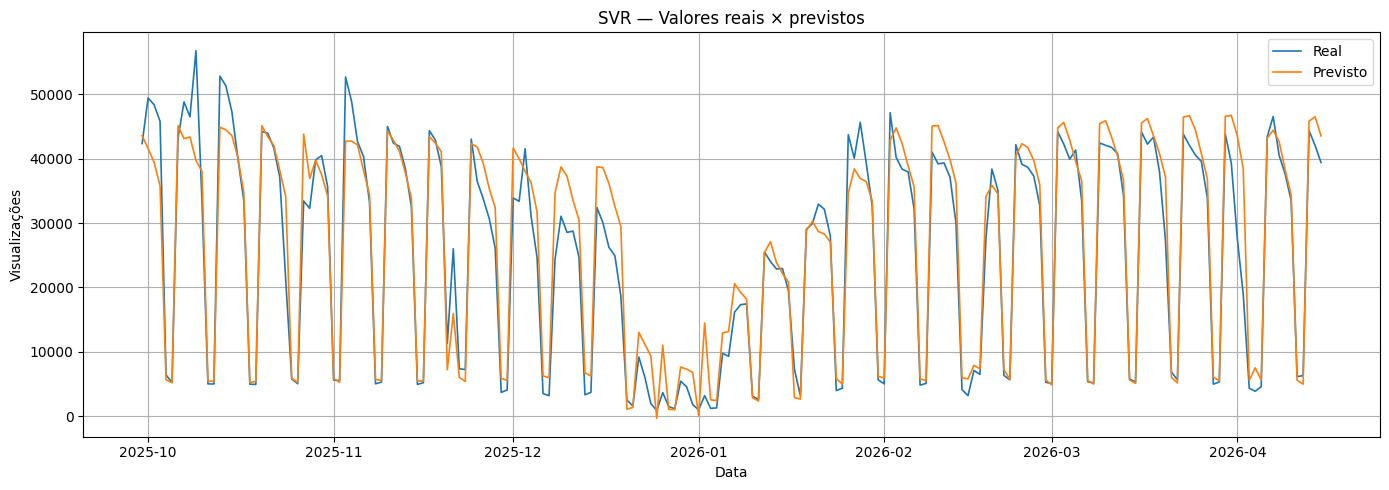

Gráfico salvo.
Arquivos salvos:
  ../dados/previsao_svr_visualizacoes.csv
  ../dados/metricas_svr.csv
  ../resultados/figuras/svr_real_vs_previsto.png


In [1]:
#*- coding: utf-8 -*-
"""
Modelo SVR — Previsão de visualizações diárias do Portal do TRT18
Metodologia alinhada ao ARIMA e SARIMAX:
  - base comum: trafego_tratado.csv
  - split sequencial treino/teste 80/20, sem embaralhamento
  - métricas: MAE, RMSE e R²
  - gráfico real × previsto no mesmo padrão dos demais notebooks
"""
 
import os
import warnings
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
warnings.filterwarnings("ignore")
 
# ============================================================
# 1. Leitura da base tratada comum
# ============================================================
df = pd.read_csv("../dados/trafego_tratado.csv")
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data").reset_index(drop=True)
 
# ============================================================
# 2. Seleção de variáveis e engenharia de atributos
# ============================================================
# Apenas atributos conhecidos com antecedência ou derivados do
# histórico passado. Sessões e usuários ativos são excluídos por
# serem contemporâneos à variável-alvo (vazamento de informação).
colunas_svr = [
    "Data", "Visualizações",
    "dia_semana", "fim_de_semana", "mes",
    "recesso_judiciario", "feriado_nacional_fixo", "carnaval",
    "quarta_cinzas", "sexta_paixao", "corpus_christi",
    "data_especifica_judiciario", "ponto_facultativo_emenda",
]
df_svr = df[colunas_svr].copy()
 
# Defasagens da variável-alvo (apenas valores anteriores ao dia previsto)
df_svr["vis_lag_1"]  = df_svr["Visualizações"].shift(1)
df_svr["vis_lag_7"]  = df_svr["Visualizações"].shift(7)
df_svr["vis_lag_30"] = df_svr["Visualizações"].shift(30)
 
# Médias móveis defasadas (shift(1) garante que o próprio dia não entra)
df_svr["vis_mm_7"]  = df_svr["Visualizações"].shift(1).rolling(window=7).mean()
df_svr["vis_mm_30"] = df_svr["Visualizações"].shift(1).rolling(window=30).mean()
 
# ============================================================
# 3. Remoção de linhas sem histórico suficiente
# ============================================================
df_svr = df_svr.dropna().reset_index(drop=True)
 
# ============================================================
# 4. Separação temporal treino/teste — 80/20 (igual ARIMA/SARIMAX)
# ============================================================
tamanho_treino = int(len(df_svr) * 0.8)
 
y = df_svr["Visualizações"]
X = df_svr.drop(columns=["Data", "Visualizações"])
 
X_train = X.iloc[:tamanho_treino].copy()
X_test  = X.iloc[tamanho_treino:].copy()
y_train = y.iloc[:tamanho_treino].copy()
y_test  = y.iloc[tamanho_treino:].copy()
datas_test = df_svr["Data"].iloc[tamanho_treino:].copy()
 
print("Total de observações (após lags):", len(df_svr))
print("Treino:", len(X_train), "| Teste:", len(X_test))
print("Período de teste:", datas_test.min().date(), "→", datas_test.max().date())
 
# ============================================================
# 5. Modelo SVR com ajuste de hiperparâmetros
#    Pipeline (StandardScaler → SVR): a normalização é ajustada
#    apenas sobre os dados de treino de cada fold, evitando
#    vazamento de informações futuras.
# ============================================================
pipeline_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr",    SVR(kernel="rbf")),
])
 
param_grid = {
    "svr__C":       [1000, 5000, 10000, 50000],
    "svr__epsilon": [100,  500,  1000,  2000],
    "svr__gamma":   ["scale", 0.001, 0.01, 0.1],
}
 
# Validação cruzada respeitando a ordem temporal
tscv = TimeSeriesSplit(n_splits=5)
 
grid_svr = GridSearchCV(
    estimator=pipeline_svr,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    verbose=0,
)
grid_svr.fit(X_train, y_train)
melhor_modelo = grid_svr.best_estimator_
 
print("\nMelhores parâmetros:", grid_svr.best_params_)
 
# ============================================================
# 6. Previsão no conjunto de teste e métricas
# ============================================================
y_pred = melhor_modelo.predict(X_test)
 
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
 
print("\n" + "=" * 55)
print("AVALIAÇÃO FINAL — SVR (teste: 20% final da série)")
print("=" * 55)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")
print("=" * 55)
 
# ============================================================
# 7. Gráfico real × previsto
# ============================================================
os.makedirs("../resultados/figuras", exist_ok=True)
 
plt.figure(figsize=(14, 5))
plt.plot(datas_test.values, y_test.values, label="Real",     linewidth=1.2)
plt.plot(datas_test.values, y_pred,        label="Previsto", linewidth=1.2)
plt.title("SVR — Valores reais × previstos")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../resultados/figuras/svr_real_vs_previsto.png", dpi=150)
plt.show()
print("Gráfico salvo.")
 
# ============================================================
# 8. Salvamento de previsões e métricas
# ============================================================
os.makedirs("../dados", exist_ok=True)
 
df_previsao = pd.DataFrame({
    "Data":     datas_test.values,
    "Real":     y_test.values,
    "Previsto": y_pred,
})
df_previsao.to_csv("../dados/previsao_svr_visualizacoes.csv", index=False)
 
metricas_svr = pd.DataFrame({
    "Modelo":     ["SVR"],
    "Parametros": [str(grid_svr.best_params_)],
    "MAE":        [mae],
    "RMSE":       [rmse],
    "R2":         [r2],
})
metricas_svr.to_csv("../dados/metricas_svr.csv", index=False)
 
print("Arquivos salvos:")
print("  ../dados/previsao_svr_visualizacoes.csv")
print("  ../dados/metricas_svr.csv")
print("  ../resultados/figuras/svr_real_vs_previsto.png")